<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Experiments/experiments_excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
DATA_PATH = "/content/Excel_All_Features.csv"
LABEL_COL = "label"

In [ ]:
# 2. Load data
df = pd.read_csv(DATA_PATH)
print ("Dataset Dimensions: ", df.shape)
display (df.head())
print (df[LABEL_COL].value_counts())

Dataset Dimensions:  (20000, 50)


,file_path,file_size,sheet_count,max_rows,max_cols,total_cells,non_empty_cells,numeric_cell_count,string_cell_count,formula_count,...,macro_count_parentheses,macro_count_assignments,macro_max_line_length,macro_max_string_literals,macro_max_arithmetic_ops,macro_max_concat_ops,macro_vocab_size,preview_image_width,preview_image_height,label
0,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,739072,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,/content/drive/MyDrive/UNB/Mastercard project/...,58846,1,450,12,5400,4652,1579,3073,0,...,0,0,35,0,2,0,5211,0,0,0
2,/content/drive/MyDrive/UNB/Mastercard project/...,223714,2,2516,10,25164,19458,6445,13013,1,...,2,1,39,0,2,0,12384,0,0,0
3,/content/drive/MyDrive/UNB/Mastercard project/...,506774,4,2742,18,59955,46267,15349,30918,3,...,6,3,39,0,2,0,17441,0,0,0
4,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,155136,1,117,12,1404,10,1,9,0,...,6,11,3080,14,2,14,78,0,0,1


label
1    10000
0    10000
Name: count, dtype: int64


In [ ]:
# 3. Check for dataset types, missing values and unique values
FEATURES_COLS = df.columns.drop(['file_path', 'label'])
check = pd.DataFrame ({
    "dtype" : df.dtypes.astype(str),
    "missing_count" : df.isna().sum(),
    "missing_rate" : df.isna().mean(),
    "unique_count" : df.nunique(dropna=True)

}).sort_values (["missing_rate", "unique_count"], ascending=[False, True])

display (check)
print("Exact duplicated rows:", df.duplicated(subset=FEATURES_COLS).sum())


,dtype,missing_count,missing_rate,unique_count
ocr_extracted_text_length,int64,0,0.0,1
preview_image_text_entropy,int64,0,0.0,1
deceptive_keywords_count_ocr,int64,0,0.0,1
macro_callbyname_count,int64,0,0.0,1
preview_image_width,int64,0,0.0,1
preview_image_height,int64,0,0.0,1
hex_pattern_count,int64,0,0.0,2
has_macro,int64,0,0.0,2
macro_count,int64,0,0.0,2
uses_file_api,int64,0,0.0,2


Exact duplicated rows: 6028


In [ ]:
# 4. detect the label distribution among duplicate rows
duplicate_rows = df[df.duplicated(subset=FEATURES_COLS, keep=False)]

print("Duplicated-row label counts:")
print(duplicate_rows[LABEL_COL].value_counts())

Duplicated-row label counts:
label
1    6591
Name: count, dtype: int64


In [ ]:
# 5. Remove exact duplicated rows before splitting
df_clean = df.drop_duplicates(subset=FEATURES_COLS).reset_index(drop=True)

print("Shape after duplicate removal:", df_clean.shape)
print("Class counts after duplicate removal:")
print(df_clean[LABEL_COL].value_counts())

Shape after duplicate removal: (13972, 50)
Class counts after duplicate removal:
label
0    10000
1     3972
Name: count, dtype: int64


In [ ]:
# 6. Detect one-valued columns
dead_cols = [col for col in FEATURES_COLS if df_clean[col].nunique() == 1]

print(f"Fully dead columns ({len(dead_cols)}):")
for col in dead_cols:
    print(f"  {col}  -> constant value: {df_clean[col].unique()[0]}")

Fully dead columns (6):
  ocr_extracted_text_length  -> constant value: 0
  preview_image_text_entropy  -> constant value: 0
  deceptive_keywords_count_ocr  -> constant value: 0
  macro_callbyname_count  -> constant value: 0
  preview_image_width  -> constant value: 0
  preview_image_height  -> constant value: 0


In [ ]:
# 7. Detect exactly duplicated feature columns
# update FEATURES_COLS after deleting dead columns
df_without_dead_cols = df_clean.drop(
    columns=['file_path', 'label'] + dead_cols,
    errors='ignore'
)

duplicate_feature_pairs = []
for i, col1 in enumerate(df_without_dead_cols.columns):
  for col2 in df_without_dead_cols.columns [i+1 :] :
    if df_without_dead_cols[col1].equals(df_without_dead_cols[col2]):
      duplicate_feature_pairs.append((col1, col2))

display (
    pd.DataFrame (
        duplicate_feature_pairs,
        columns=["kept_candidate", "duplicate_candidate"]
    )
)

# Drop only the second occurrence of each exact duplicate pair.
duplicate_feature_cols_to_drop = sorted({b for _, b in duplicate_feature_pairs}) # _ to ignore the first item
print ("Exact duplicate feature columns to drop: ", duplicate_feature_cols_to_drop)

# df_clean = df_clean.drop(columns=['macro_vocab_size', 'macro_count'])
# print ("Dataset shape after dropping duplicate rows and columns: " , df_clean.shape)

,kept_candidate,duplicate_candidate
0,has_macro,macro_count
1,macro_token_count,macro_vocab_size


Exact duplicate feature columns to drop:  ['macro_count', 'macro_vocab_size']


In [ ]:
# 8. Fixed train/test split
# The same test set is used for every model and every training size experiment
X = df_clean[FEATURES_COLS]
y = df_clean[LABEL_COL]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# # undersampling experiment
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)

# X_train_full, y_train = rus.fit_resample(X_train_full, y_train)

print("Train:", X_train_full.shape, y_train.value_counts().to_dict())
print("Test :", X_test_full.shape, y_test.value_counts().to_dict())

Train: (9780, 48) {0: 7000, 1: 2780}
Test : (4192, 48) {0: 3000, 1: 1192}


## Feature sets

We compare three conditions:

- **Raw-All:** all non-duplicate raw features. This shows the optimistic performance of the original representation.
- **Raw-Leakage-Reduced:** exact duplicate columns and uni-valued columns are excluded.
- **Unified-Leakage-Reduced:** a small interpretable representation constructed only from leakage-reduced features.


In [ ]:
# 9. Define raw feature sets
raw_all_cols = [
    c for c in X_train_full.columns
    if c not in duplicate_feature_cols_to_drop
]

raw_safe_cols = [
    c for c in raw_all_cols
    if c not in dead_cols
]

print("Raw-All features:", len(raw_all_cols))
print("Raw-Safe features:", len(raw_safe_cols))
print("Excluded uni-valued features:", len(set(raw_all_cols) - set(raw_safe_cols)))

X_train_full.shape


Raw-All features: 46
Raw-Safe features: 40
Excluded uni-valued features: 6


(9780, 48)

In [ ]:
# Feature Construction
def calculate_content_density (col, df):
  token = df[col]
  total_tokens = df['macro_token_count']
  return np.where (total_tokens > 0, token / total_tokens, 0)

def calculate_sheet_ratio (col, df):
  sheet_type = df [col]
  total_sheets = df ['sheet_count']
  return np.where (total_sheets > 0, sheet_type / total_sheets, 0)

def calculate_cell_density (col, df):
  cell_type = df [col]
  total_cells = df ['total_cells']
  return np.where (total_cells > 0, cell_type / total_cells, 0)

# text_volume
df_clean['text_volume'] = np.where(
    df_clean['non_empty_cells'] > 0,
    df_clean['avg_cell_length'] * (df_clean['string_cell_count'] + df_clean['numeric_cell_count']) / df_clean['non_empty_cells'],
    0
)

# renaming remote_template_present to remote_template_count
df_clean['remote_template_count'] = df_clean['remote_template_present']
df_clean = df_clean.drop(columns=['remote_template_present'])

# comment density -> active_content_density
df_clean['comment_density'] = np.where(
    df_clean['macro_line_count'] > 0,
    df_clean['macro_comment_lines'] / df_clean['macro_line_count'],
    0
)

# macro complexity category (parantheses & assignments) -> active_content_density
df_clean ['parentheses_density'] = calculate_content_density ('macro_count_parentheses', df_clean)
df_clean ['assignments_density'] = calculate_content_density ('macro_count_assignments', df_clean)


# string reconstruction category (chr & concat & str fun) -> obfsucation_score
df_clean ['chr_density'] = calculate_content_density ('macro_chr_count', df_clean)
df_clean ['concatenation_density'] = calculate_content_density ('macro_concatenation_count', df_clean)
df_clean ['string_functions_density'] = calculate_content_density ('macro_string_function_count', df_clean)

# expression complexity (arthimatic opr) -> obfsucation_score
df_clean ['arthimatic_opr_density'] = calculate_content_density ('macro_arithmetic_operator_count', df_clean)


# workbook level score (hidden, protected, empty) -> structure_complexity_score
df_clean ['hidden_sheets_ratio'] = calculate_sheet_ratio ('hidden_sheets_count', df_clean)
df_clean ['protected_sheets_ratio'] = calculate_sheet_ratio ('protected_sheets_count', df_clean)
df_clean ['empty_sheets_ratio'] = calculate_sheet_ratio ('empty_sheet_count', df_clean)

# calculate sheet area -> structure_complexity_score
sheet_area = df_clean ['max_rows'] * df_clean ['max_cols']
df_clean ['worksheet_dimensions_score'] = np.log1p(sheet_area)

# worksheet_content_score -> structure_complexity_score
df_clean ['formula_density'] = calculate_cell_density ('formula_count', df_clean)

# presentation_layout_score (txt format, merged cells) -> structure_complexity_score
df_clean ['text_formatting_density'] = calculate_cell_density ('rich_text_formatting_count', df_clean)
df_clean ['merged_cells_density'] = calculate_cell_density ('merged_cells_count', df_clean)

df_clean.shape

(13972, 65)

In [ ]:
# check for skewed features
def find_skewed_columns(X, threshold=1.0):

    numeric_data = X.select_dtypes(include="number")


    skewness = numeric_data.skew().sort_values(
        key=abs,
        ascending=False
    )

    skewed_columns = skewness[skewness.abs() >= threshold]

    return skewed_columns

skewed_columns = find_skewed_columns(
    df_clean,
    threshold=30.0
)

print(skewed_columns)

hex_pattern_count              118.203215
macro_max_concat_ops            84.459625
formula_count                   80.000774
total_cells                     78.857747
rich_text_formatting_count      78.776615
macro_comment_lines             77.982389
macro_max_string_literals       74.946768
parentheses_density             70.628655
macro_count_parentheses         70.396730
base64_pattern_count            69.608407
macro_procedure_count           66.605217
macro_string_function_count     65.191600
macro_count_assignments         63.118714
hyperlink_count                 58.390941
named_ranges_count              58.178980
arthimatic_opr_density          55.176223
macro_concatenation_count       52.109039
merged_cells_count              51.847775
comment_density                 50.394317
concatenation_density           48.014899
string_functions_density        43.893832
chr_density                     43.476466
protected_sheets_count          39.501208
remote_template_count           36

In [ ]:
# 10. Unified features
# NOTES:)
# - log is applied to columns before scaling to handel the outlier.
# - scaler parameters are fitted on training data only to avoid data leakage!!


BASE_UNIFIED_GROUPS = {
    #1
    "file_size" : [
        'file_size'
    ],

    #2
    "text_size" : [
        'text_volume'
    ],

    #3
    "embedded_objects": [
        0
        ],

    #4
    "active_content_score": [
        'has_macro',
        'uses_file_api',
        'uses_network_api',
        'uses_process_api'
    ],

    #5
    "active_content_density": {
        'avg_macro_size': [
            'macro_token_count',
            'macro_line_count',
            'macro_procedure_count'
        ],
        'comment_density': [
            'comment_density',
        ],
        'macro_complexity_score': [
            'parentheses_density',
            'assignments_density'
        ]
    },


    "external_reference_count": {
        "external_reference_count": [
            'hyperlink_count',
            'remote_template_count'
        ]
    },

    #7
    "obfuscation_score" : {
        'encoding_score': [
            'base64_pattern_count',
            'hex_pattern_count',
            'entropy_of_text'
        ],
        'string_reconstruction_score': [
            'chr_density',
            'concatenation_density',
            'string_functions_density',
            'macro_max_line_length',
            'macro_average_line_length'
        ],
        'expression_complexity_score': [
            'macro_max_string_literals',
            'macro_max_arithmetic_ops',
            'macro_max_concat_ops',
            'arthimatic_opr_density'
        ]
    },

    #8
    "structural_complexity_score": {
        'workbook_level' :[
            'sheet_count',
            'named_ranges_count',
            'hidden_sheets_ratio',
            'protected_sheets_ratio',
            'empty_sheets_ratio'
        ],
        'worksheet_dimensions' : [
            'worksheet_dimensions_score'
        ],
        'worksheet_content' : [
            'formula_density',
            'total_cells'
        ],
        'presentation_layout' : [
            'merged_cells_density',
            'text_formatting_density'
        ]
    }
}
LOG_COLUMNS = {
    'hex_pattern_count',
    'macro_max_concat_ops',
    'formula_count',
    'total_cells',
    'rich_text_formatting_count',
    'macro_comment_lines',
    'macro_max_string_literals',
    'parentheses_density',
    'macro_count_parentheses',
    'base64_pattern_count',
    'macro_procedure_count',
    'macro_string_function_count',
    'macro_count_assignments',
    'hyperlink_count',
    'named_ranges_count',
    'arthimatic_opr_density',
    'macro_concatenation_count',
    'merged_cells_count',
    'string_functions_density',
    'comment_density',
    'concatenation_density',
    'chr_density',
    'protected_sheets_count',
    'remote_template_count',
    'avg_cell_length',
    'text_volume',
    'macro_max_arithmetic_ops',
    'macro_average_line_length',
    'max_cols',
}

BINARY_GROUPS = {
    'active_content_score'
}

In [ ]:
# split after adding the features
X_uni = df_clean.drop(columns=["label"])
y_uni = df_clean["label"]

X_uni_train, X_uni_test, y_uni_train, y_uni_test = train_test_split(
    X_uni,
    y_uni,
    test_size=0.30,
    random_state=42,
    stratify=y_uni
)

# # undersampling experiment
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)

# X_uni_train, y_uni_train = rus.fit_resample(X_uni_train, y_uni_train)

In [ ]:
# 11. Fit/transform unified features without leakage
# ceate dataframes that only contains the indcies of X_uni_train and X_uni_test
X_train_unified = pd.DataFrame(index=X_uni_train.index)
X_test_unified = pd.DataFrame(index=X_uni_test.index)
group_scalers = {}
scaler = MinMaxScaler()

# loop through every group (total of 8 iterations)
for group_name, spec in BASE_UNIFIED_GROUPS.items():

    # --- Handle the embedded_objects placeholder (no real data, fixed 0) ---
    if spec == [0]:
        X_train_unified[group_name] = 0
        X_test_unified[group_name] = 0
        continue # to end the loop here and go to the next group

    # --- Detect flat groups (list of raw columns) vs nested groups (dict of sub-clusters) ---
    is_nested = isinstance(spec, dict)
    sub_specs = spec if is_nested else {group_name: spec} # if it's already a dict, use it as-is. If it's a flat list, wrap it into a fake single-entry dict {"file_size": ['file_size']}

    # collect one computed number-per-row for each sub-cluster.
    sub_train_scores = {}
    sub_test_scores = {}

    for sub_name, columns in sub_specs.items():

        missing_columns = [c for c in columns if c not in X_uni_train.columns]
        if missing_columns:
            print(group_name, sub_name, "missing:", missing_columns)
            continue

        # take a copy of columns of the subcluster only, from the cleaf_df copy
        train_values = X_uni_train[columns].copy()
        test_values = X_uni_test[columns].copy()

        # Log-transform BEFORE scaling — write back into train_values/test_values, not the output frame
        for col in columns:
            if col in LOG_COLUMNS:
                train_values[col] = np.log1p(train_values[col].clip(lower=0))
                test_values[col] = np.log1p(test_values[col].clip(lower=0))

        # get max for binary columns
        if group_name == "active_content_score":
            sub_train_scores[sub_name] = train_values.max(axis=1)
            sub_test_scores[sub_name] = test_values.max(axis=1)

        # scaling non-binary columns and get their mean
        else:
            train_scaled = scaler.fit_transform(train_values)
            test_scaled = scaler.transform(test_values) # becomes np array

            train_scaled = pd.DataFrame(
                train_scaled,
                index=train_values.index,
                columns=train_values.columns
            )

            test_scaled = pd.DataFrame(
                test_scaled,
                index=test_values.index,
                columns=test_values.columns
            )

            sub_train_scores[sub_name] = train_scaled.mean(axis=1)
            sub_test_scores[sub_name] = test_scaled.mean(axis=1)

            group_scalers[f"{group_name}.{sub_name}"] = scaler


    # --- Roll up sub-cluster scores into the final unified feature ---
    if not sub_train_scores:
        continue

    sub_train_df = pd.DataFrame(sub_train_scores)
    sub_test_df = pd.DataFrame(sub_test_scores)

    X_train_unified[group_name] = sub_train_df.mean(axis=1) # skipna=True
    X_test_unified[group_name] = sub_test_df.mean(axis=1)

In [ ]:
# save the Unified features Dataframe
X_train_unified.to_csv("X_train_unified.csv", index=False)
X_test_unified.to_csv("X_test_unified.csv", index=False)
Excel_unified_features = pd.concat([X_train_unified, X_test_unified], axis=0)
Excel_unified_features.to_csv("Word_unified_features.csv", index=False)

In [ ]:
# 12. Model definitions
models = {
    "Logistic_L1": Pipeline([
        ("imputer", SimpleImputer(strategy='constant', fill_value=0)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=1.0,
            max_iter=100,
            random_state=RANDOM_STATE
        ))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy='constant', fill_value=0)),
        ("model", RandomForestClassifier(
            n_estimators=25,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

     "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy='constant', fill_value=0)),
        ("model", XGBClassifier(
            n_estimators=25,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])
}

In [ ]:
# 13. Evaluation helper
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, feature_set):
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    pred = fitted.predict(X_test)

    if hasattr(fitted, "predict_proba"):
        score = fitted.predict_proba(X_test)[:, 1]
    else:
        score = fitted.decision_function(X_test)

    return fitted, {
        "feature_set": feature_set,
        "model": model_name,
        "n_features": X_train.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro",),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, score),
        "pr_auc": average_precision_score(y_test, score)
    }

In [ ]:
# 14. Compare Raw-All, Raw-Safe, and Unified-Safe
feature_sets = {
    "Raw_All": (
        X_train_full[raw_all_cols],
        X_test_full[raw_all_cols]
    ),
    "Raw_Leakage_Reduced": (
        X_train_full[raw_safe_cols],
        X_test_full[raw_safe_cols]
    ),
    "Unified_Leakage_Reduced": (
        X_train_unified,
        X_test_unified
    )
}

comparison_results = []
fitted_models = {}

for feature_set_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        fitted, result = evaluate_model(
            model, Xtr, y_train, Xte, y_test,
            model_name=model_name,
            feature_set=feature_set_name
        )
        comparison_results.append(result)
        fitted_models[(feature_set_name, model_name)] = fitted

comparison_df = pd.DataFrame(comparison_results)

display(comparison_df)
comparison_df.to_csv("model_comparison_results.csv", index=False)

,feature_set,model,n_features,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
0,Raw_All,Logistic_L1,46,0.999284,0.999500,0.998742,0.999120,0.999805,0.999619
1,Raw_All,RandomForest,46,0.999523,0.999162,0.999667,0.999414,1.000000,1.000000
2,Raw_All,XGBoost,46,0.998807,0.998661,0.998408,0.998534,0.999997,0.999993
3,Raw_Leakage_Reduced,Logistic_L1,40,0.999284,0.999500,0.998742,0.999120,0.999806,0.999620
4,Raw_Leakage_Reduced,RandomForest,40,0.999523,0.999162,0.999667,0.999414,1.000000,0.999999
5,Raw_Leakage_Reduced,XGBoost,40,0.998569,0.998493,0.997989,0.998241,0.999997,0.999992
6,Unified_Leakage_Reduced,Logistic_L1,8,0.894323,0.866171,0.880158,0.872660,0.933148,0.919446
7,Unified_Leakage_Reduced,RandomForest,8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,Unified_Leakage_Reduced,XGBoost,8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


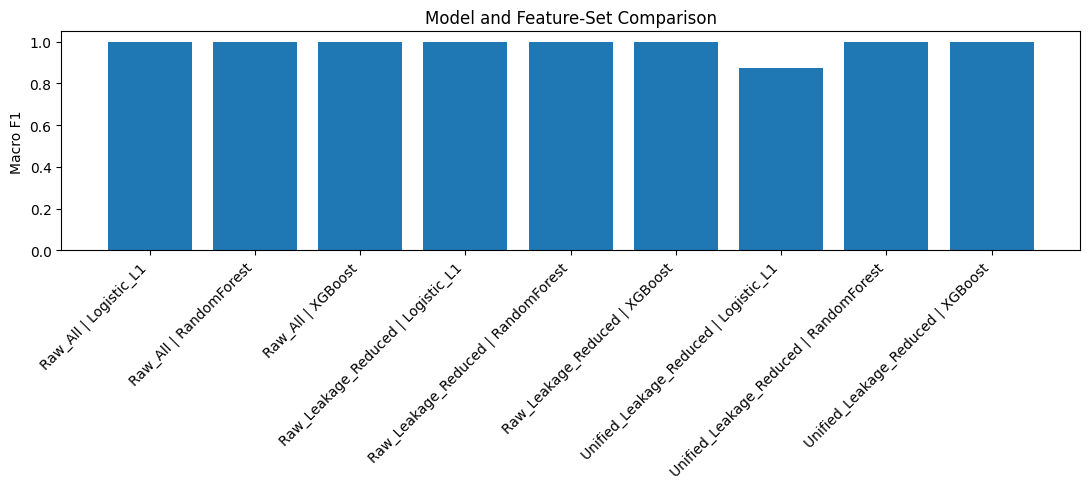

In [ ]:
# 15. Visual Comparison
plot_df = comparison_df.copy()
labels = plot_df["feature_set"] + " | " + plot_df["model"]

plt.figure(figsize=(11, 5))
plt.bar(labels, plot_df["f1_macro"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1")
plt.title("Model and Feature-Set Comparison")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
# 16. L1/LASSO selected features from leakage-reduced raw data
lasso_model = fitted_models[("Raw_All", "Logistic_L1")]
coef = lasso_model.named_steps["model"].coef_[0]

lasso_features = pd.DataFrame({
    "feature": raw_all_cols,
    "coefficient": coef,
    "absolute_coefficient": np.abs(coef)
}).sort_values("absolute_coefficient", ascending=False)

selected_lasso_features = lasso_features.loc[
    lasso_features["absolute_coefficient"] > 1e-8, "feature"
].tolist()

display(lasso_features)
print("Selected by L1:", len(selected_lasso_features))
print(selected_lasso_features)
lasso_features.to_csv("lasso_feature_ranking.csv", index=False)


,feature,coefficient,absolute_coefficient
0,file_size,19.472937,19.472937
28,macro_token_count,-10.090227,10.090227
27,macro_average_line_length,9.391675,9.391675
24,macro_concatenation_count,6.066227,6.066227
21,macro_chr_count,-5.794434,5.794434
15,remote_template_present,5.537032,5.537032
11,entropy_of_text,-4.056920,4.056920
23,macro_arithmetic_operator_count,-1.141557,1.141557
1,sheet_count,1.097799,1.097799
36,empty_sheet_count,0.684997,0.684997


Selected by L1: 20
['file_size', 'macro_token_count', 'macro_average_line_length', 'macro_concatenation_count', 'macro_chr_count', 'remote_template_present', 'entropy_of_text', 'macro_arithmetic_operator_count', 'sheet_count', 'empty_sheet_count', 'avg_cell_length', 'uses_process_api', 'macro_count_parentheses', 'max_rows', 'macro_max_line_length', 'macro_string_function_count', 'uses_file_api', 'numeric_cell_count', 'total_cells', 'base64_pattern_count']


In [ ]:
# 17. Evaluate LASSO-selected raw feature subset
if selected_lasso_features:
    selected_results = []

    for model_name, model in models.items():
        _, result = evaluate_model(
            model,
            X_train_full[selected_lasso_features],
            y_train,
            X_test_full[selected_lasso_features],
            y_test,
            model_name=model_name,
            feature_set="LASSO_Selected_Raw"
        )
        selected_results.append(result)

    selected_df = pd.DataFrame(selected_results)
    display(selected_df)

    comparison_df = pd.concat(
        [comparison_df, selected_df],
        ignore_index=True
    ).sort_values(["f1_macro", "pr_auc"], ascending=False)

    comparison_df.to_csv("model_comparison_results.csv", index=False)

,feature_set,model,n_features,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
0,LASSO_Selected_Raw,Logistic_L1,20,0.999284,0.999500,0.998742,0.999120,0.999808,0.999622
1,LASSO_Selected_Raw,RandomForest,20,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,LASSO_Selected_Raw,XGBoost,20,0.998569,0.998493,0.997989,0.998241,0.999998,0.999994


In [ ]:
selected_lasso_features

['file_size',
 'macro_token_count',
 'macro_average_line_length',
 'macro_concatenation_count',
 'macro_chr_count',
 'remote_template_present',
 'entropy_of_text',
 'macro_arithmetic_operator_count',
 'sheet_count',
 'empty_sheet_count',
 'avg_cell_length',
 'uses_process_api',
 'macro_count_parentheses',
 'max_rows',
 'macro_max_line_length',
 'macro_string_function_count',
 'uses_file_api',
 'numeric_cell_count',
 'total_cells',
 'base64_pattern_count']